In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 90 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main am

In [2]:
## -- System dependencies --
import sys, os, gc
import torch
import pydot
import tensorflow as tf

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

2026-06-09 17:42:40.407180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781026960.643427      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781026960.711207      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781026961.274810      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781026961.274906      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781026961.274909      17 computation_placer.cc:177] computation placer alr

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ['KERAS_BACKEND'] = 'tensorflow'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

tf.keras.utils.set_random_seed(CFG['SEED'])

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [7]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [8]:
train.describe() 

,alpha,delta,u,g,r,i,z,redshift,class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


In [9]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


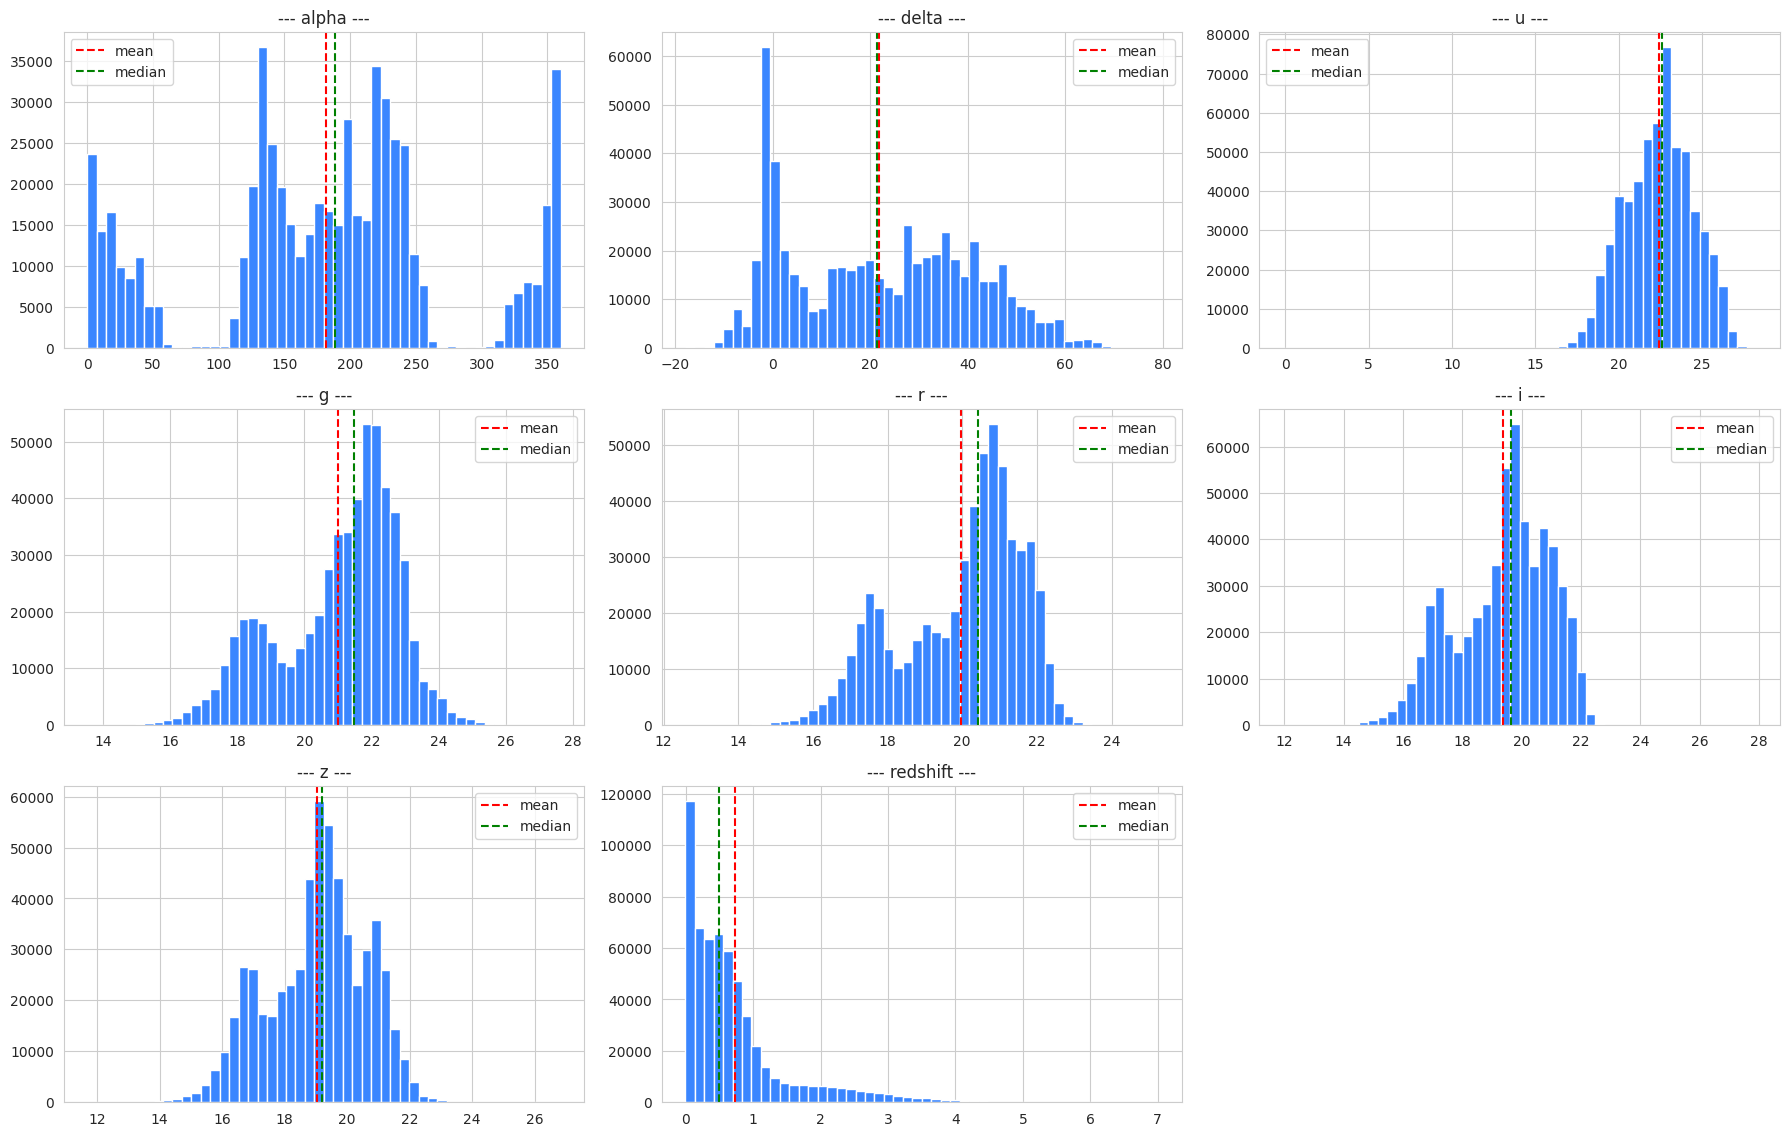

In [11]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()

plt.tight_layout()
plt.show()

## FEATURE ENGINEERING

In [12]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> {label: weight}
    """
    if opt != 'auto':
        return opt
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        class_weights = dict(zip(cls_, wts_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [13]:
## -- Extractions & Binnig --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
 
round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     for r in range(-3, 6):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
# for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 5):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     print(f"\nQuantile binning.. ", end='')
#     for q in [90, 180, 360]: 
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
## -- Arithmetic interaction --
# u - g, g - r, r - i, i - z

# ('u', 'g'),
# ('g', 'r'),
# ('i', 'z'),
# ('g', 'i'),
# ('r', 'z')

for df in tqdm([train, test, orig]):
    df['u_g_sub_'] = df['u'] - df['g']
    df['g_r_sub_'] = df['g'] - df['r']

    df['i_z_sub_'] = df['i'] - df['z']
    df['g_i_sub_'] = df['g'] - df['i']
    df['r_z_sub_'] = df['r'] - df['z']

    df['r_i_sub_'] = df['r'] - df['i']
    
    df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

    for band in ['g', 'i']:
        b_col = f"_{band}_redshift_div_"
        df[b_col] = df[band] / (df['redshift'] + 1e-6)

color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
color_bands.append('stellar_locus_dist')

train[color_bands].describe()

  0%|          | 0/3 [00:00<?, ?it/s]

,u_g_sub_,g_r_sub_,i_z_sub_,g_i_sub_,r_z_sub_,r_i_sub_,_g_redshift_div_,_i_redshift_div_,stellar_locus_dist
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,5.773470e+05,5.773470e+05,577347.000000
mean,1.434652,1.044463,0.337775,1.628362,0.921675,0.583900,9.081604e+02,8.735087e+02,0.940107
std,1.142003,0.736291,0.395797,1.073617,0.675999,0.496787,2.578451e+05,2.542172e+05,0.540065
min,-23.155858,-8.104372,-14.210769,-10.807923,-14.008533,-10.757964,-1.719873e+08,-1.713189e+08,0.001131
25%,0.598523,0.419982,0.094029,0.634816,0.412939,0.215544,2.422425e+01,2.196961e+01,0.478341
50%,1.333334,1.075605,0.343779,1.681938,0.913850,0.570048,4.149269e+01,3.716272e+01,0.878239
75%,2.087557,1.646067,0.590450,2.551026,1.412064,0.946885,9.989013e+01,9.107308e+01,1.367064
max,7.523080,8.874428,7.624849,9.284916,9.492911,8.749329,3.962015e+07,3.559959e+07,12.108608


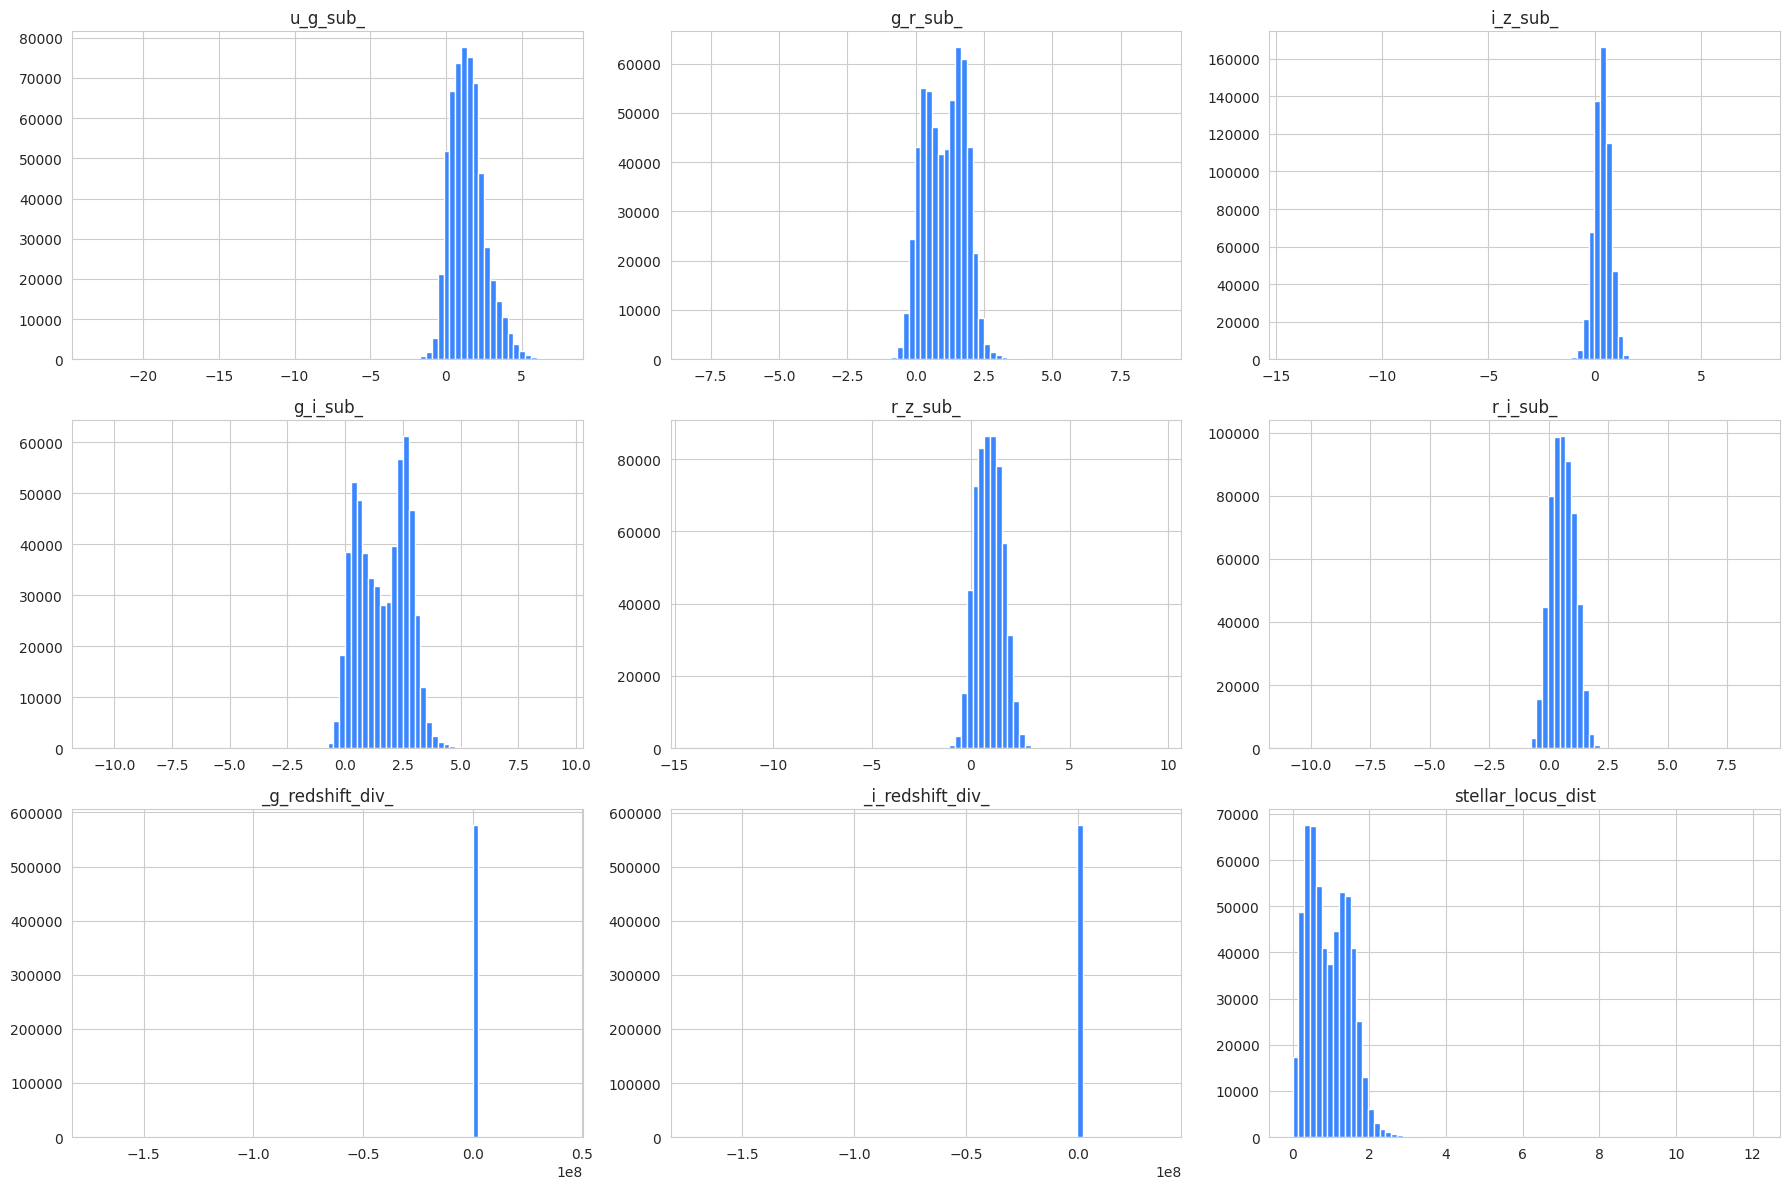

In [19]:
train[color_bands].hist(bins=80, figsize=(18, 12))
plt.tight_layout()
plt.show()

In [20]:
## -- Cyclic encoding --

for df in [train, test, orig]:
    for col in ['alpha']:
        for p in [180, 360]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

for df in [train, test, orig]:
    for col in ['delta']:
        for p in [180]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

train[cyclic_cols].head()

,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_
0,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832
1,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461
2,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684
3,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274
4,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586


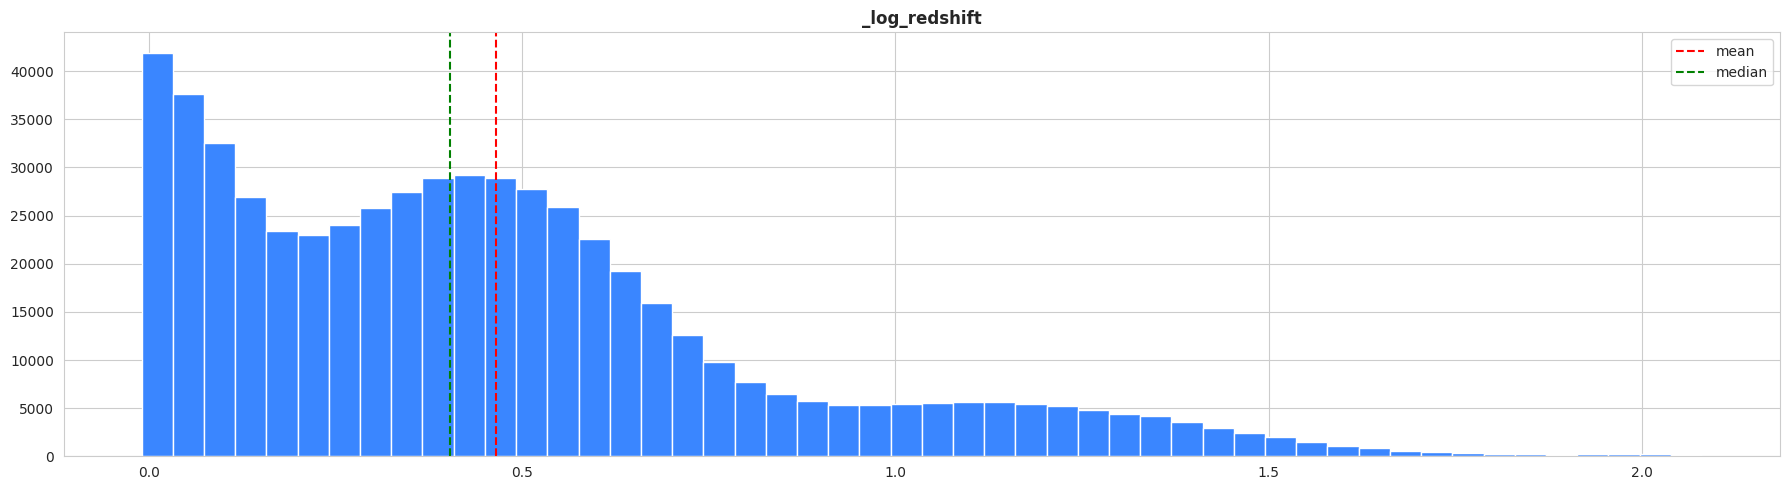

In [21]:
## -- Create log-transformed features --
for df in [train, test, orig]:
    for col in ['redshift',]:
        n_log = f"_log_{col}"
        df[n_log] = np.log1p(df[col])

log_cols = [c for c in train.columns if c.startswith('_log_')]

plt.figure(figsize=(18, 5))
for i, col in enumerate(log_cols):
    # plt.subplot(2, len(log_cols)//2, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'{col}', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [23]:
# ## -- Create log-transformed features --
# for df in [train, test, orig]:
#     for col in ['redshift',]:
#         n_log = f"_log_{col}"
#         df[n_log] = np.log1p(df[col])

# log_cols = [c for c in train.columns if c.startswith('_log_')]

# plt.figure(figsize=(18, 8))
# for i, col in enumerate(log_cols):
#     # plt.subplot(2, len(log_cols)//2, i+1)
#     plt.hist(train[col], bins=50)
#     plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [25]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [26]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [27]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# # __ = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm']

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [28]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [29]:
# plt.figure(figsize=(18, 15))
# sns.heatmap(train.corr('spearman'), annot=True, fmt='.2f', cbar=False, center=0)
# plt.show()

In [30]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 26


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,u_g_sub_,g_r_sub_,i_z_sub_,g_i_sub_,r_z_sub_,r_i_sub_,stellar_locus_dist,_g_redshift_div_,_i_redshift_div_,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_,_log_redshift
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0,3.576564,1.537632,0.636056,2.638446,1.736869,1.100813,1.326446,53.536563,47.085332,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.342868
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0,1.691447,1.499854,0.439634,1.860995,0.800775,0.361141,0.986137,120.821925,109.041746,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.146673
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1,-0.043925,-0.092712,0.025263,0.496499,0.614474,0.589211,0.700343,7.464886,7.289058,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,1.341237
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0,2.254320,2.032982,0.450706,2.685077,1.102802,0.652096,1.565502,39.266460,34.257919,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274,0.429246
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0,2.231478,1.237231,0.283262,1.572233,0.618264,0.335002,0.722251,35.035981,32.207015,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586,0.441965


# ML TRAINING

In [31]:
from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras import layers, Sequential

In [32]:
def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace=None,
    num_classes=None,
    activation='relu',
    units=[256, 128, 64],
    lr=1e-2,
    drop=0.3,
    **kwargs
    ):

    kernel_reg = tf.keras.regularizers.L2(0.0)
    use_bias = True

    # 1. Setup inputs
    dict_inputs = feature_space.get_inputs()
    encoded_features = feature_space.get_encoded_features()

    print(f"{CFG['YELLOW']}")
    print(f"Feature Inputs: {len(dict_inputs)} | Feature Space: {encoded_features.shape}")
    print(f"{CFG['RESET']}")

    # 2. Create the Sequential model
    mlp_head = Sequential([
        ## -- 1st Layer --
        layers.Dense(units[0], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
    
        ## -- 2nd Layer --
        layers.Dense(units[1], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
    
        ## -- 3rd Layer --
        layers.Dense(units[2], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
        
        ## -- Output --
        layers.Dense(num_classes, activation='softmax') 
    ])

    # 3. Connect everything
    outputs = mlp_head(encoded_features)
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

    # 4. Compile
    train_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr, weight_decay=None),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(name='loss'),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

    return train_model, infer_model

print('⚙️ Keras model ready ⚙️')

⚙️ Keras model ready ⚙️


In [33]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf, # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        learning_rate: float=1e-2,
        dropout: float=0.3,
        units = [256, 128, 64],
        eval_metric: str='val_loss', 
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.units = units
        self.eval_metric = eval_metric

        self.result = None
    
    # def _prepare_fold_data(self, X, y, X_val=None, y_val=None):
    #     # This helper can be extended to apply masks or augmentations.
    #     return X, y

    # def _df_to_ds(self, df_full, target, batch_input):
    #     df = df_full.copy()
    #     labels = df.pop(target)
    #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
    #     ds = ds.batch(batch_input)
    #     return ds

    def _feature_space_transform(self, train_full, batch_input):
        feature_specs = {}

        ## -- Handle string --
        for col in CATS:
            feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=0)

        # ## -- Handle integers --
        # for col in [c for c in BASE if train_full[c].dtype == 'object']:
        #     feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)

        ## -- Handle regular floats --
        for col in log_cols + cyclic_cols: 
            feature_specs[col] = FeatureSpace.float()
            # feature_specs[col] = FeatureSpace.float_normalized()

        ## -- Handle continuous --
        for col in NUMS + color_bands:
            # feature_specs[col] = FeatureSpace.float()
            feature_specs[col] = FeatureSpace.float_normalized()
            # feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
            # feature_specs[col] = FeatureSpace.float_rescaled(
            #     scale=1.0 / (train_data[col].max() - train_data[col].min()),
            #     offset=-train_data[col].min() / (train_data[col].max() - train_data[col].min())
            #     )

        feature_crosses = []
        for c1, c2 in itertools.combinations(CATS, 2):
            feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=4))

        # for c1, c2 in itertools.product(TOP_COLS, LOW_COLS):
        #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=8))

        _fs = FeatureSpace(
            features=feature_specs,
            crosses=feature_crosses,
            output_mode='concat',
            name='feature_processed',
        )

        print(f'⚙️ Adapting FeatureSpace.adapt() to features... ', end='')
        # ds = _df_to_ds(train_full, self.target, batch_input)

        x = train_full[self.features]
        y = train_full[self.target]

        ds = tf.data.Dataset.from_tensor_slices((dict(x), y)).batch(batch_input)
        no_labels = ds.map(lambda x, _: x)

        _fs.adapt(no_labels)

        print(f"✅ Complete!\n")
        return _fs

    # def _convert_infer_dict(self, X):
    #     if type(X) != 'dict':
    #         X = {name: tensorflow.convert_to_tensor([value]) for name, value in dict(X).items()}

    #     return X

    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n===== Starting Cross-Validation for {self.model_name} =====")
        start = time()

        num_classes = train_df[target].nunique()

        self.oof_preds  = np.zeros((len(train_df), num_classes))
        self.test_preds = np.zeros((len(test_df), num_classes))
        self.oof_scores = []
        self.fold_histories = []

        X = train_df[features]
        y = train_df[target]

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        feature_space_module = self._feature_space_transform(self.train_df, GLOBAL_BATCH_SIZE)

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n***** FOLD {idx+1}/{self.kf.n_splits} *****")
            print('-'*50)

            ## -- Split data for the current fold --
            X_train = train_df.loc[train_idx, features]
            y_train = train_df.loc[train_idx, target]
            X_val   = train_df.loc[val_idx, features]
            y_val   = train_df.loc[val_idx, target]

            X_test  = test_df[features].copy()

            ## -- Create tf.data.Datasets for train and valid --
            X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train))\
                                        .batch(GLOBAL_BATCH_SIZE)
            X_train_ds = X_train_ds.map(lambda x, y: (feature_space_module(x), y),
                                        num_parallel_calls=tf.data.AUTOTUNE)\
                                       .prefetch(tf.data.AUTOTUNE)

            X_valid_ds = tf.data.Dataset.from_tensor_slices((dict(X_val), y_val))\
                                        .batch(GLOBAL_BATCH_SIZE)
            X_valid_ds = X_valid_ds.map(lambda x, y: (feature_space_module(x), y),
                                        num_parallel_calls=tf.data.AUTOTUNE)\
                                       .prefetch(tf.data.AUTOTUNE)

            ## -- Build model --
            train_model, infer_model = self.model_builder(
                feature_space=feature_space_module,
                num_classes=num_classes,
                activation=self.activation,
                units=self.units,
                lr= self.learning_rate,
                dropout=self.dropout,
                **{} # pass additional hyperparams if needed --
            )

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor=self.eval_metric,
                    # mode=mode_monitor,
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Fit model --
            history = train_model.fit(
                X_train_ds,
                validation_data=X_valid_ds,
                class_weight=get_class_weights(y_train, y_train),
                epochs=self.epochs,
                callbacks=callbacks,
                verbose=2,
            )
            self.fold_histories.append(history.history)

            ## -- Make predictions with infer_model --
            X_val_ds = tf.data.Dataset.from_tensor_slices(dict(X_val)).batch(GLOBAL_BATCH_SIZE)
            self.oof_preds[val_idx] = infer_model.predict(X_val_ds)

            print(f"Predictions Output Type: {type(infer_model.predict(X_val_ds))}")

            fold_score = balanced_acc(y_val, self.oof_preds[val_idx])
            self.oof_scores.append(fold_score)
            print(f"{CFG['YELLOW']} • Fold {idx + 1} Score: {fold_score:.5f}{CFG['RESET']}")

            X_test_ds = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
            self.test_preds += infer_model.predict(X_test_ds)

            ## -- Save fold infer_model --
            infer_model.save(f"{CHECKPOINT}infer_model_{idx+1}.keras")

        self.test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.oof_scores, 1):
            print(f" • Fold {i} Score: {score:.5f}")

        overall_score  = np.round(balanced_acc(y, self.oof_preds), 5)
        avg_fold_score = np.round(np.mean(self.oof_scores), 5)
        std_fold_score = np.round(np.std(self.oof_scores), 5)

        print("-------------------------------------------------|")
        print(f"OOF Score: {overall_score}")
        print(f"AVG Score: {avg_fold_score} ± {std_fold_score}")
        print("-------------------------------------------------|")
        print(f'{((time() - start) / 60):.2f} mins\n')

        print()
        display(train_model.summary(expand_nested=True))

        return {
            'avg_score': avg_fold_score,
            'final_score': overall_score,
            'scores': self.oof_scores,
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'val_data': [X_val_ds, y_val],
            'history': self.fold_histories,
        }

print('⚙️ Model trainer ready ⚙️')


⚙️ Model trainer ready ⚙️


In [34]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,u_g_sub_,g_r_sub_,i_z_sub_,g_i_sub_,r_z_sub_,r_i_sub_,stellar_locus_dist,_g_redshift_div_,_i_redshift_div_,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_,_log_redshift
57755,218.819434,41.098809,22.887579,21.175022,19.556668,18.977441,18.468760,0.593716,M,Red_Sequence,0,1.712557,1.618353,0.508681,2.197581,1.087908,0.579227,1.146635,35.665192,31.963796,0.976818,0.214073,-0.626868,-0.779125,0.990742,0.135757,0.466068
467513,130.913983,23.389843,22.004053,20.884906,20.875059,20.912494,20.807225,1.466239,A/F,Blue_Cloud,1,1.119148,0.009846,0.105269,-0.027588,0.067834,-0.037435,0.585556,14.243855,14.262671,-0.989846,-0.142146,0.755694,-0.654925,0.728726,0.684806,0.902694
53590,218.918237,-1.918078,19.879133,18.069553,16.768183,16.242324,15.955112,0.086661,M,Red_Sequence,0,1.809580,1.301370,0.287213,1.827229,0.813071,0.525858,0.828636,208.505637,187.421138,0.977550,0.210703,-0.628211,-0.778043,-0.066904,0.997759,0.083110


In [35]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [36]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [37]:
%%time

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

## -- Start training --
version_name = f'keras_fe0_'

CFG['FOLDS'] = 5
LR           = 0.001
EPOCHS       = 100
PATIENCE     = 10
BATCH_SIZE   = 64
DROPOUT      = 0.1
UNITS        = [256, 128, 64]

all_predictions = {}

for VALUE in [0]: # 
    trainer = TrainerCV(
        model_builder = build_keras_model,
        model_name = version_name,
        train_df = train_data,
        test_df = test,
        features = FEATURES,
        target = TARGET,
        kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED']),
        batch_size = BATCH_SIZE,
        activation = 'silu',
        units = UNITS,
        epochs = EPOCHS,
        patience = PATIENCE,
        learning_rate = LR,
        dropout = DROPOUT,
        eval_metric = 'val_accuracy',
    )

    result = trainer.fit()
    all_predictions[f"_{VALUE}"] = result['final_score']


===== Starting Cross-Validation for keras_fe0_ =====
⚙️ Number of devices: 1
⚙️ Adapting FeatureSpace.adapt() to features... 

2026-06-09 17:43:09.606380: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Complete!


***** FOLD 1/5 *****
--------------------------------------------------

Feature Inputs: 26 | Feature Space: (None, 34)

Epoch 1/100
7217/7217 - 37s - 5ms/step - accuracy: 0.9210 - loss: 0.1870 - val_accuracy: 0.9379 - val_loss: 0.1683
Epoch 2/100
7217/7217 - 35s - 5ms/step - accuracy: 0.9349 - loss: 0.1517 - val_accuracy: 0.9379 - val_loss: 0.1644
Epoch 3/100
7217/7217 - 35s - 5ms/step - accuracy: 0.9387 - loss: 0.1435 - val_accuracy: 0.9434 - val_loss: 0.1498
Epoch 4/100
7217/7217 - 35s - 5ms/step - accuracy: 0.9402 - loss: 0.1395 - val_accuracy: 0.9432 - val_loss: 0.1504
Epoch 5/100
7217/7217 - 35s - 5ms/step - accuracy: 0.9417 - loss: 0.1363 - val_accuracy: 0.9438 - val_loss: 0.1481
Epoch 6/100
7217/7217 - 36s - 5ms/step - accuracy: 0.9422 - loss: 0.1358 - val_accuracy: 0.9476 - val_loss: 0.1396
Epoch 7/100
7217/7217 - 37s - 5ms/step - accuracy: 0.9428 - loss: 0.1339 - val_accuracy: 0.9464 - val_loss: 0.1419
Epoch 8/100
7217/7217 - 37s - 5ms/step - accuracy: 0.9436 - 

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_30CLONE            │ (None, 34)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 3)              │        52,099 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_16 (Dense)           │ (None, 256)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_12     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_12 (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_17 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_13     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_13 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_18 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_14     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_14 (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_19 (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 51,203 (200.01 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 102,408 (400.04 KB)

None

CPU times: user 3h 30min 31s, sys: 19min 32s, total: 3h 50min 4s
Wall time: 1h 41min 57s


In [38]:
# use_bias = True --------------------------------| ✅
#  • Fold 1 Score: 0.94628
#  • Fold 2 Score: 0.94062
#  • Fold 3 Score: 0.94413
#  • Fold 4 Score: 0.94719
#  • Fold 5 Score: 0.94993
# -------------------------------------------------|
# OOF Score: 0.94563
# AVG Score: 0.94563 ± 0.00312
# -------------------------------------------------|
# 7.36 mins

# use_bias = False --------------------------------|
#  • Fold 1 Score: 0.94584
#  • Fold 2 Score: 0.94055
#  • Fold 3 Score: 0.93817
#  • Fold 4 Score: 0.94607
#  • Fold 5 Score: 0.94707
# -------------------------------------------------|
# OOF Score: 0.94354
# AVG Score: 0.94354 ± 0.00352
# -------------------------------------------------|
# 6.21 mins

In [39]:
all_predictions

{'_0': np.float64(0.95807)}

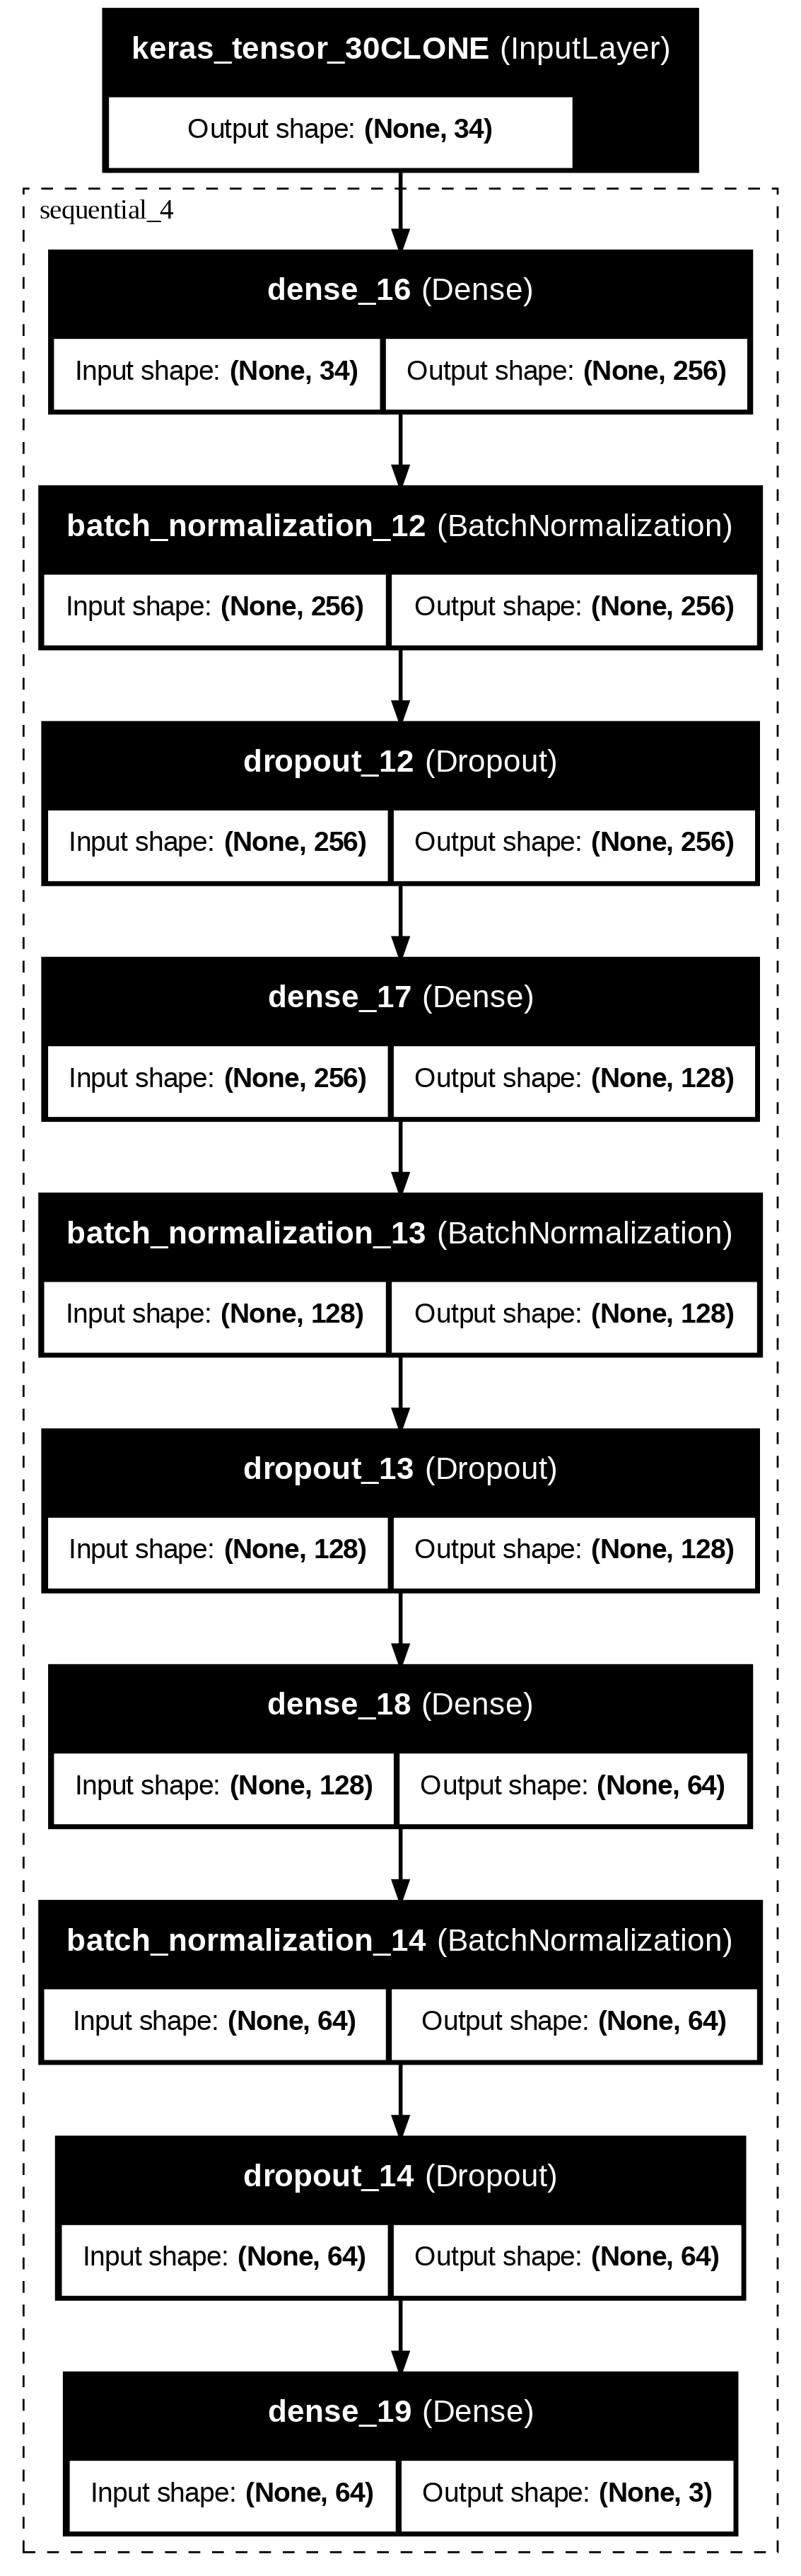

In [40]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")

tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

  0%|          | 0/5 [00:00<?, ?it/s]

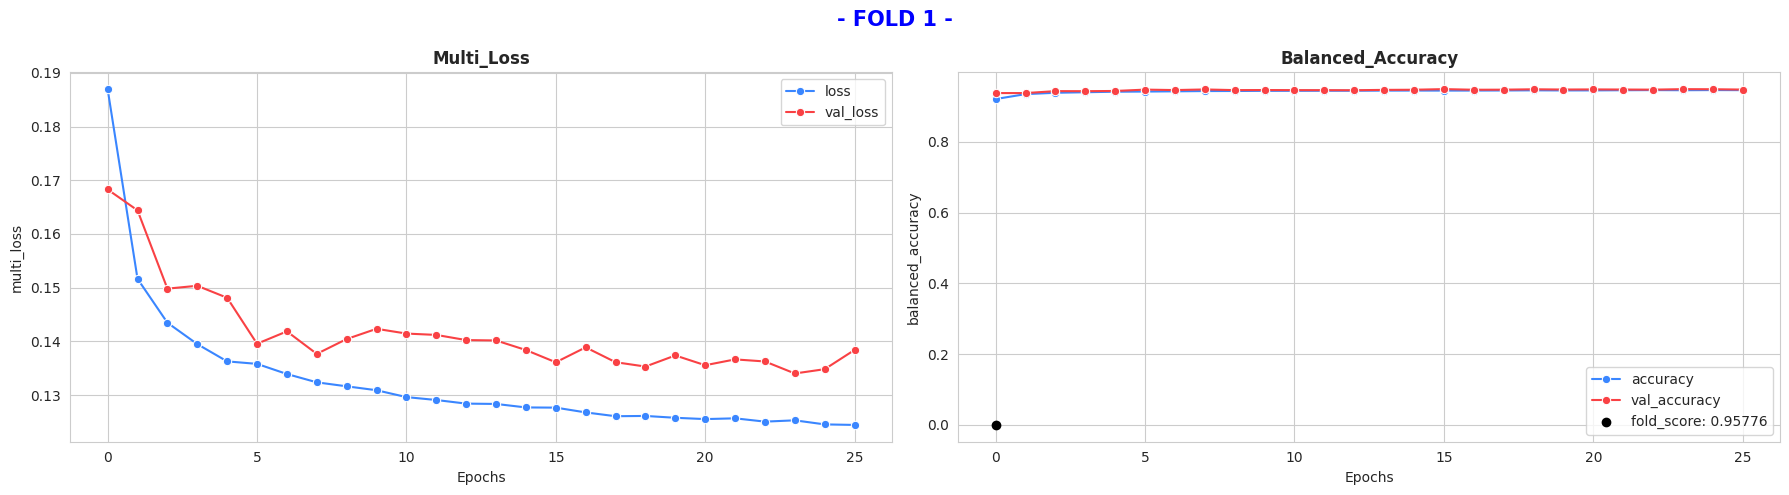

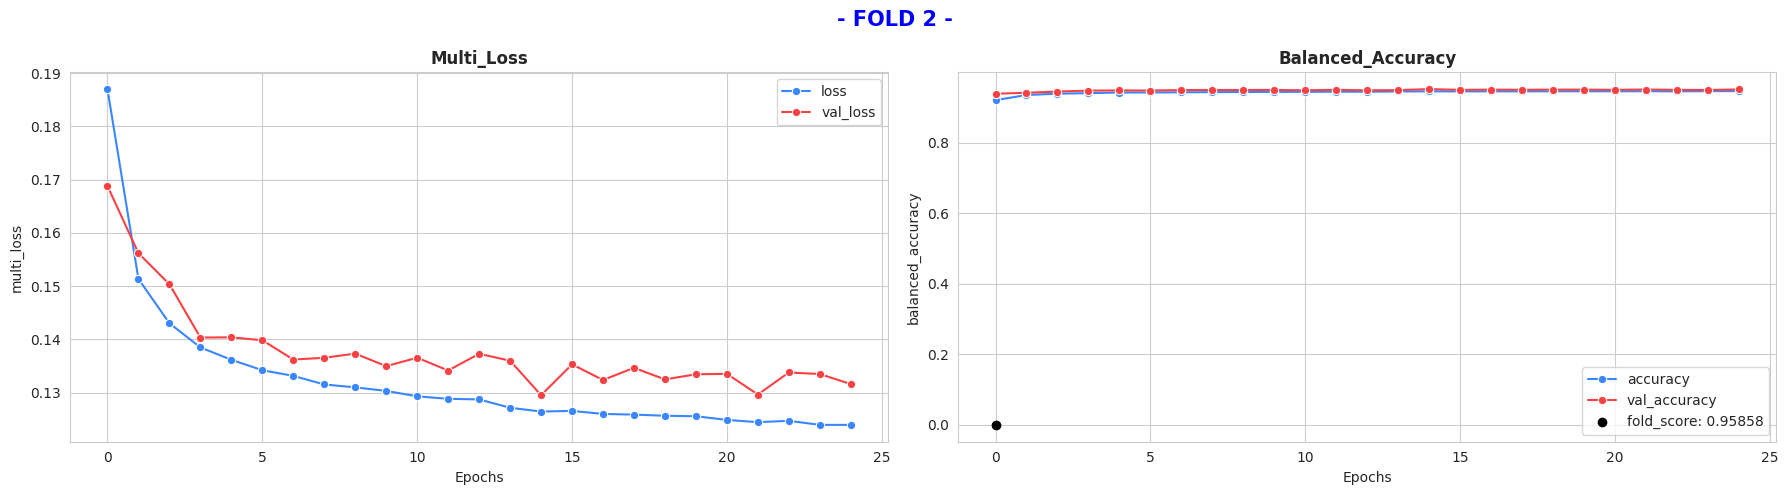

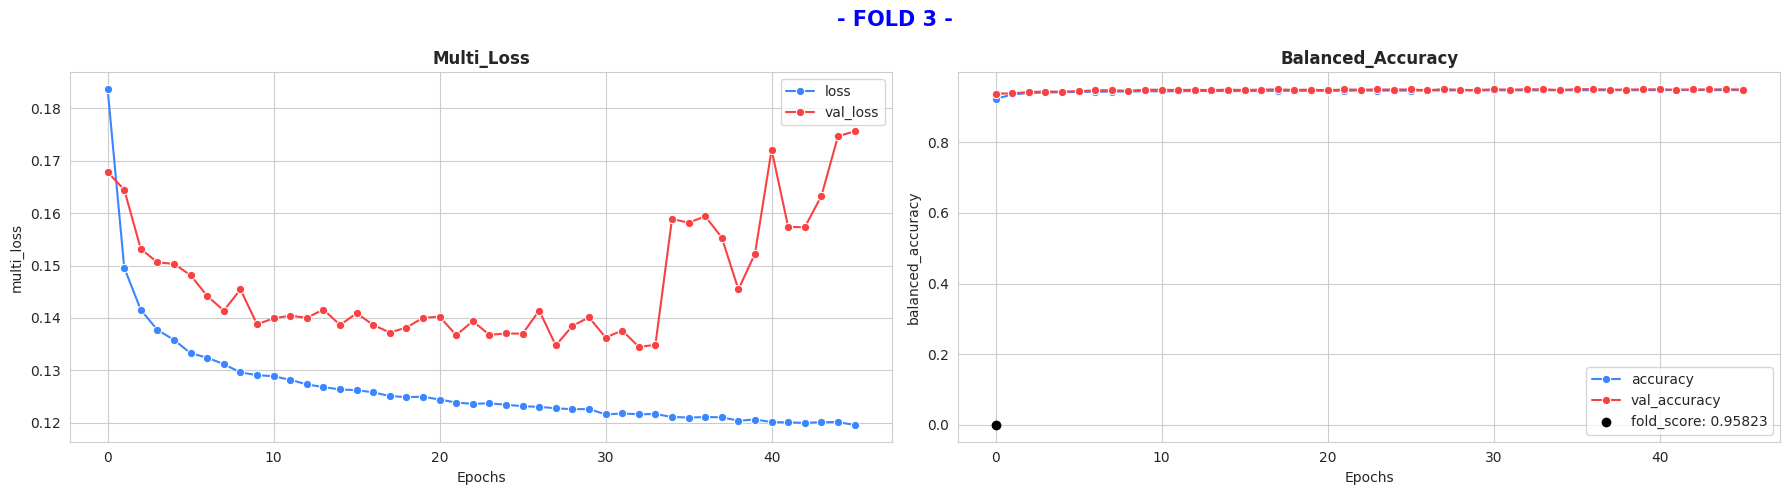

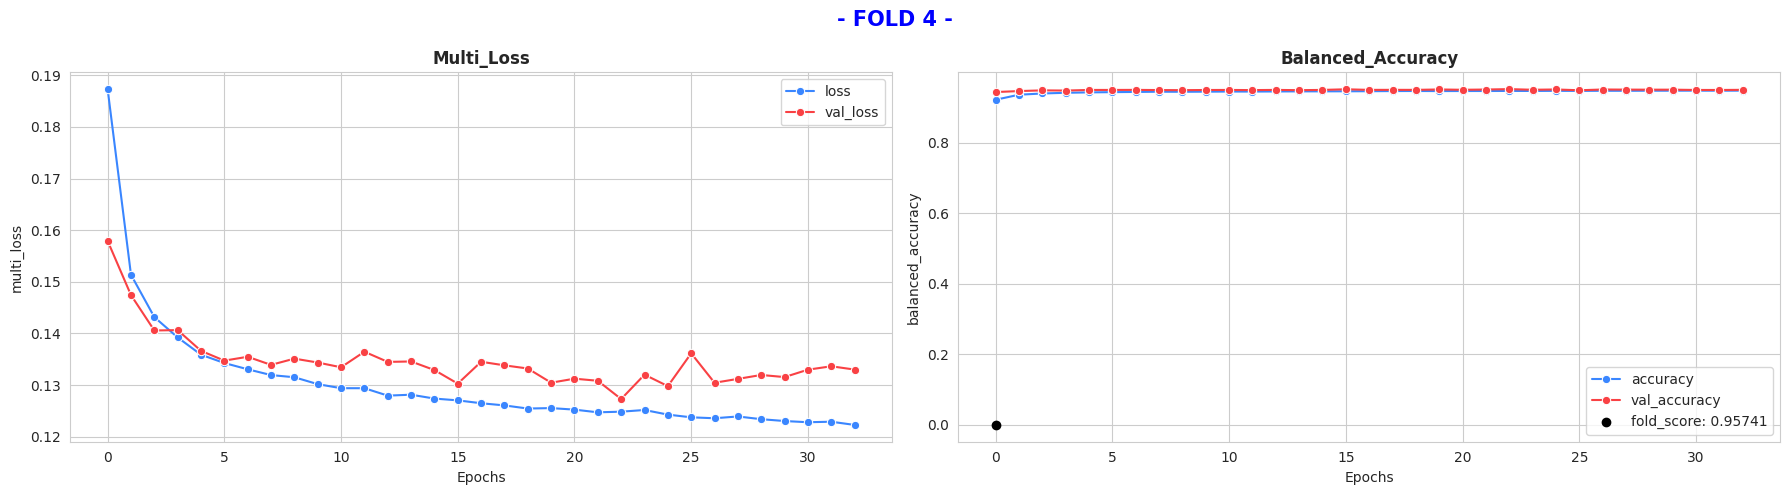

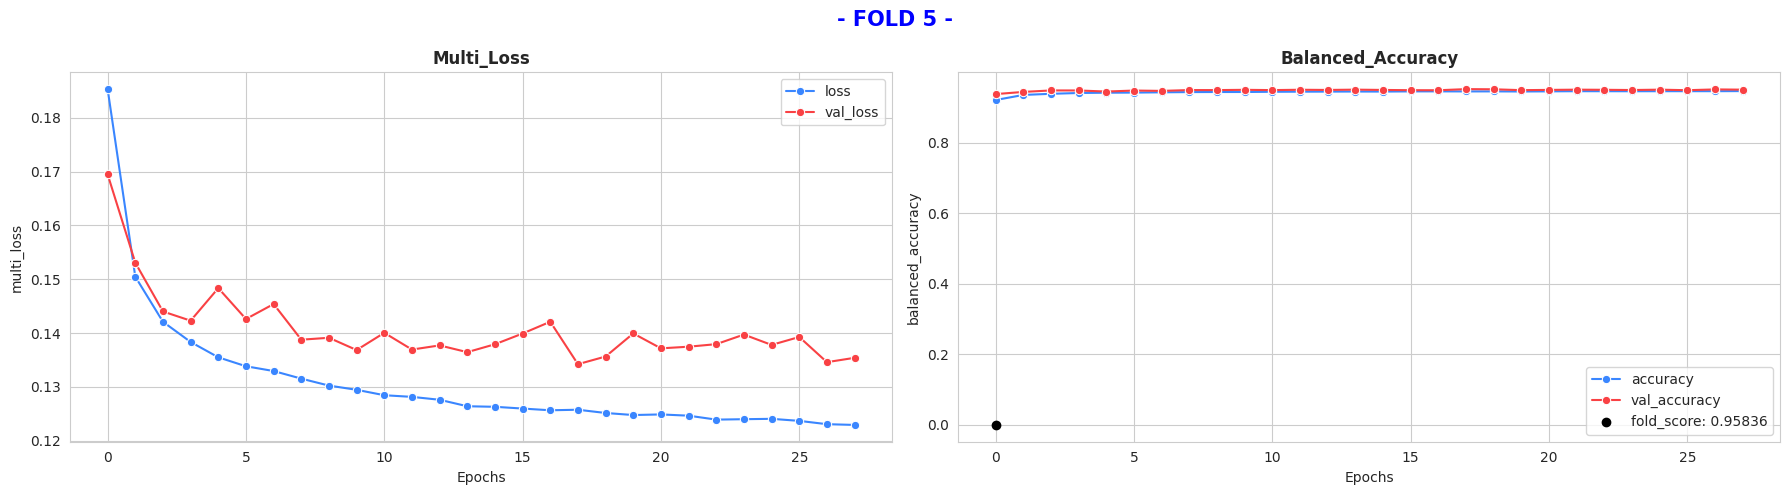

In [41]:
## -- PLOTTING RESULTS --
histories = result['history']

for i, data in tqdm(enumerate(histories), total=len(histories)):
    loss_results = pd.DataFrame({'loss': data['loss'], 'val_loss': data['val_loss']})
    acc_results = pd.DataFrame({'accuracy': data['accuracy'], 'val_accuracy': data['val_accuracy']})
    
    plt.figure(figsize=(18, 5))
    marker = 'o'

    ## -- PLOT 1: LOSS --
    plt.subplot(121)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.loss, label='loss', marker=marker)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
    plt.title('Multi_Loss', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('multi_loss')

    ## -- PLOT 2: ACCURACY --
    plt.subplot(122)
    sns.lineplot(acc_results, x=acc_results.index, y=acc_results.accuracy, label='accuracy', marker=marker)
    sns.lineplot(acc_results, x=acc_results.index, y=acc_results.val_accuracy, label='val_accuracy', marker=marker)
    plt.title('Balanced_Accuracy', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('balanced_accuracy')

    stat_ = f"fold_score: {result['scores'][i]:.5f}"
    plt.scatter(x=0, y=0, label=stat_, color='k')

    plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print()

In [42]:
n = version_name + str(np.round(np.mean(result['final_score']), 5)).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'])
np.save(f'test_{n}.npy', result['test_preds'])

submit[TARGET] = pd.Series(np.argmax(result['test_preds'], axis=1)).map(r_mapping)
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Submission file exported as: 'submit_{n}.csv'")
submit.head(10)

Submission file exported as: 'submit_keras_fe0_95807.csv'


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY
